<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Email_Spam_Detection_using_Multinomial_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Columns: Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')
Missing values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
Accuracy: 97.8743961352657
Confusion Matrix:
[[731  11]
 [ 11 282]]


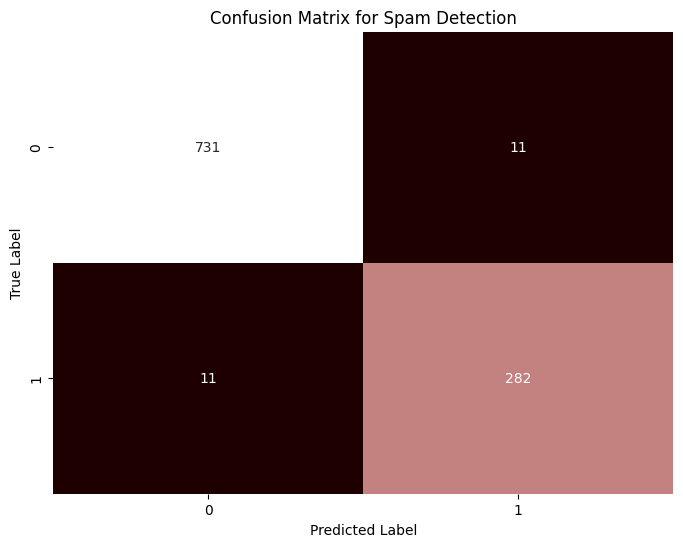

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

# Load your dataset
df = pd.read_csv("spam_ham_dataset.csv")

print("Dataset:")
print(df.head())

# Check column names
print("Columns:", df.columns)

# Handle missing values
print("Missing values:")
print(df.isnull().sum())
df = df.dropna()

# ---- IMPORTANT: Adjust column names if needed ----
# Assume:
# 'label' = spam/ham
# 'text' = email content

# If your dataset uses different names, change here:
# Example: df['Category'], df['Message']

X_text = df['text']      # change if needed
y = df['label']          # change if needed

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Convert text to numeric
cv = CountVectorizer()
X = cv.fit_transform(X_text)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)
print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Spam Detection")
plt.show()